In [1]:
import pandas as pd

In [5]:
ds1 = pd.read_csv("datasets/ds1_main.csv")
ds2 = pd.read_csv("datasets/ds2_lifestyle.csv")
ds3 = pd.read_csv("datasets/ds3_social-media.csv")
ds5 = pd.read_csv("datasets/ds4_social-wellbeing.csv")

In [3]:
display(list(ds2.columns))

['student_id',
 'age',
 'gender',
 'study_hours_per_day',
 'social_media_hours',
 'netflix_hours',
 'part_time_job',
 'attendance_percentage',
 'sleep_hours',
 'diet_quality',
 'exercise_frequency',
 'parental_education_level',
 'internet_quality',
 'mental_health_rating',
 'extracurricular_participation',
 'exam_score']

In [4]:
display(list(ds1.columns))

['student_id',
 'age',
 'gender',
 'grade_level',
 'study_hours_per_day',
 'uses_ai',
 'ai_usage_time_minutes',
 'ai_tools_used',
 'ai_usage_purpose',
 'ai_dependency_score',
 'ai_generated_content_percentage',
 'ai_prompts_per_week',
 'ai_ethics_score',
 'last_exam_score',
 'assignment_scores_avg',
 'attendance_percentage',
 'concept_understanding_score',
 'study_consistency_index',
 'improvement_rate',
 'sleep_hours',
 'social_media_hours',
 'tutoring_hours',
 'class_participation_score',
 'final_score',
 'passed',
 'performance_category']

# Relation to DS5: Social Wellbeing

Here, we see that ds1 doesn't have psycological factors, which might influence student's grade as well, thus we can try to enrich those features from another datasets as well.

- Common features that they have: (Age, daily_social_media_hr, daily_sleep_hours, study_work_hours_per_day)
- Features we want to extract: (Wellbeing_index, Burntout Risk )

In [5]:
list(ds5.columns)

['Age',
 'Gender',
 'Country',
 'Student_Working_Status',
 'Daily_Social_Media_Hours',
 'Screen_Time_Hours',
 'Night_Scrolling_Frequency',
 'Online_Gaming_Hours',
 'Content_Type_Preference',
 'Exercise_Frequency_per_Week',
 'Daily_Sleep_Hours',
 'Caffeine_Intake_Cups',
 'Study_Work_Hours_per_Day',
 'Overthinking_Score',
 'Anxiety_Score',
 'Mood_Stability_Score',
 'Social_Comparison_Index',
 'Sleep_Quality_Score',
 'Motivation_Level',
 'Emotional_Fatigue_Score',
 'Wellbeing_Index',
 'Burnout_Risk']

In [7]:
ds5 = ds5.rename(columns={
    "Daily_Social_Media_Hours": "social_media_hours",
    "Age": "age",
    "Gender": "gender",
    "Daily_Sleep_Hours": "sleep_hours",
    "Study_Work_Hours_per_Day": "study_work_hours",
    "Wellbeing_Index": "wellbeing_index",
    "Burnout_Risk": "burnout_risk",
    "Motivation_Level": "motivation_level"
})

features = ["social_media_hours", "age", "gender", "sleep_hours", "study_work_hours", "wellbeing_index", "burnout_risk"]

ds5_features = ds5[features]
display(ds5_features.head(20))

,social_media_hours,age,gender,sleep_hours,study_work_hours,wellbeing_index,burnout_risk
0,4.81,24,Male,6.84,11.42,4.28,Medium
1,4.16,21,Male,7.88,6.98,5.23,Medium
2,3.07,25,Male,6.39,7.79,3.72,High
3,4.41,22,Female,7.92,6.61,3.97,High
4,2.97,24,Male,5.97,4.81,4.63,Medium
5,6.06,20,Male,6.70,6.44,3.44,High
6,3.68,24,Male,5.18,6.66,3.65,High
7,4.64,25,Female,6.27,6.29,2.82,High
8,6.50,22,Male,6.78,10.66,3.27,High
9,3.73,21,Female,4.65,9.88,3.85,High


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Features for wellbeing prediction
features_wellbeing = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours"
]

X = ds5[features_wellbeing].copy()
y = ds5["wellbeing_index"]

# Convert categorical
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict
pred = lin_model.predict(X_test)

# Metrics
print("Linear Regression R2:", r2_score(y_test, pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, pred))
print("Linear Regression RMSE:", root_mean_squared_error(y_test, pred))


# Coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_model.coef_
})

print(coef_df.sort_values(by="coefficient", ascending=False))

Linear Regression R2: 0.49789170102592495
Linear Regression MAE: 0.6930408826711897
Linear Regression RMSE: 0.877159076147595
              feature  coefficient
2         sleep_hours     0.725831
1                 age    -0.005150
3    study_work_hours    -0.006078
5   gender_Non-binary    -0.017752
4         gender_Male    -0.026096
0  social_media_hours    -0.109755


In [8]:
ds5["wellbeing_index"].describe()

count    10000.000000
mean         3.870213
std          1.238940
min          1.000000
25%          3.020000
50%          3.870000
75%          4.700000
max          8.860000
Name: wellbeing_index, dtype: float64

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

features = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours"
]

X = ds5[features].copy()
y = ds5["wellbeing_index"]

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred))
print("Random Forest MAE:", mean_absolute_error(y_test, pred))

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances)

Random Forest R2: 0.45813291470512485
Random Forest MAE: 0.7212285597410774
              feature  importance
2         sleep_hours    0.630156
0  social_media_hours    0.153330
3    study_work_hours    0.139534
1                 age    0.055336
4         gender_Male    0.013251
5   gender_Non-binary    0.008392


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# -------------------------
# Features & Target
# -------------------------
features = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours"
]

X = ds5[features].copy()
y = ds5["wellbeing_index"]

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# Train/Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Scaling (VERY IMPORTANT)
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Neural Network
# -------------------------
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

pred = nn.predict(X_test_scaled)

print("Neural Network R2:", r2_score(y_test, pred))
print("Neural Network MAE:", mean_absolute_error(y_test, pred))

Neural Network R2: 0.48712493288801306
Neural Network MAE: 0.7000641306403084


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

features_burnout = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours",
]

X = ds5[features_burnout].copy()
y = ds5["burnout_risk"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(
    max_iter=1000,
    multi_class="ovr"
)

log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.752
              precision    recall  f1-score   support

        High       0.77      0.80      0.78      1100
         Low       0.00      0.00      0.00        11
      Medium       0.73      0.70      0.72       889

    accuracy                           0.75      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.75      0.75      0.75      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/

## Transfer to DS1

In [36]:
ds1["study_work_hours"] = ds1["study_hours_per_day"] + ds1["tutoring_hours"]
transfer_features = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours"
]

X_ds1 = ds1[transfer_features].copy()

display('DS1')
display(X_ds1.describe(include="all"))


display('DS5')
display(ds5[features].describe(include="all"))

'DS1'

,social_media_hours,age,gender,sleep_hours,study_work_hours
count,8000.000000,8000.00000,8000,8000.000000,8000.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Male,NaN,NaN
freq,NaN,NaN,3908,NaN,NaN
mean,3.010600,18.96725,NaN,6.465025,5.810325
std,1.744974,3.15316,NaN,1.435670,2.124516
min,0.000000,14.00000,NaN,4.000000,0.700000
25%,1.500000,16.00000,NaN,5.200000,4.300000
50%,3.000000,19.00000,NaN,6.400000,5.800000
75%,4.500000,22.00000,NaN,7.700000,7.300000


'DS5'

,social_media_hours,age,gender,sleep_hours,study_work_hours
count,10000.000000,10000.000000,10000,10000.000000,10000.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Male,NaN,NaN
freq,NaN,NaN,4547,NaN,NaN
mean,4.005883,21.992900,NaN,6.512031,6.030983
std,1.480509,2.589309,NaN,1.194194,1.975337
min,0.500000,18.000000,NaN,3.000000,1.000000
25%,3.010000,20.000000,NaN,5.710000,4.700000
50%,3.990000,22.000000,NaN,6.520000,6.030000
75%,4.982500,24.000000,NaN,7.320000,7.340000


<Axes: xlabel='social_media_hours', ylabel='Density'>

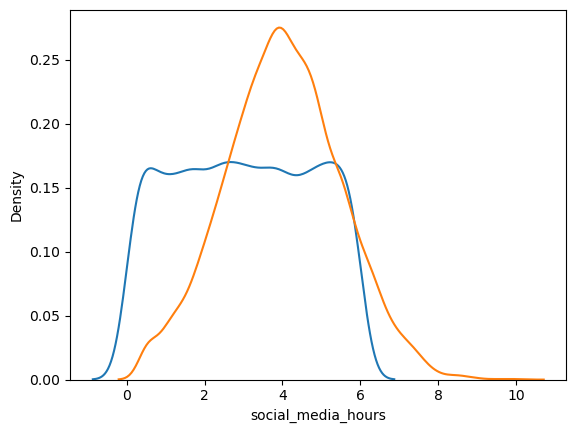

In [37]:
import seaborn as sns

sns.kdeplot(ds1["social_media_hours"], label="DS1")
sns.kdeplot(ds5["social_media_hours"], label="DS5")

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# -------------------------
# Features
# -------------------------
features = [
    "social_media_hours",
    "age",
    "sleep_hours",
    "study_work_hours"
]

# Gender handled separately
X = ds5[features].copy()
y = ds5["wellbeing_index"]

# Scale numeric variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame (important for clarity)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# Add gender dummy
gender_dummy = pd.get_dummies(ds5["gender"], drop_first=True)
X_scaled = pd.concat([X_scaled, gender_dummy], axis=1)

# Train model
lin_model = LinearRegression()
lin_model.fit(X_scaled, y)

print("Model trained on standardized DS5.")

Model trained on standardized DS5.


In [23]:
# -------------------------
# Prepare DS1
# -------------------------

# Create study_work_hours
ds1["study_work_hours"] = (
    ds1["study_hours_per_day"] + ds1["tutoring_hours"]
)

X_ds1 = ds1[features].copy()

# Apply SAME scaler (DO NOT refit!)
X_ds1_scaled = scaler.transform(X_ds1)
X_ds1_scaled = pd.DataFrame(X_ds1_scaled, columns=features)

# Add gender dummy (must match training structure)
gender_dummy_ds1 = pd.get_dummies(ds1["gender"], drop_first=True)

X_ds1_scaled = pd.concat([X_ds1_scaled, gender_dummy_ds1], axis=1)

# Align columns
X_ds1_scaled = X_ds1_scaled.reindex(columns=X_scaled.columns, fill_value=0)

# -------------------------
# Predict Wellbeing
# -------------------------
ds1["predicted_wellbeing"] = lin_model.predict(X_ds1_scaled)

print(ds1[["predicted_wellbeing"]].head())

   predicted_wellbeing
0             4.644843
1             4.545572
2             3.675380
3             5.081322
4             5.882625


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# -------------------------
# Features (NO wellbeing_index)
# -------------------------
features_burnout = [
    "social_media_hours",
    "age",
    "gender",
    "sleep_hours",
    "study_work_hours"
]

X5 = ds5[features_burnout].copy()
y5 = ds5["burnout_risk"]

# One-hot encode gender
X5 = pd.get_dummies(X5, columns=["gender"], drop_first=True)

# Separate numeric columns
numeric_cols = ["social_media_hours", "age", "sleep_hours", "study_work_hours"]

# Scale numeric features
scaler_burn = StandardScaler()
X5[numeric_cols] = scaler_burn.fit_transform(X5[numeric_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42, stratify=y5
)

# Train logistic regression
log_model = LogisticRegression(max_iter=2000, multi_class="ovr")
log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

print("Scaled DS5 Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Save column structure for DS1 alignment
train_cols = X5.columns

Scaled DS5 Accuracy: 0.743
              precision    recall  f1-score   support

        High       0.76      0.79      0.77      1078
         Low       0.00      0.00      0.00        13
      Medium       0.72      0.70      0.71       909

    accuracy                           0.74      2000
   macro avg       0.49      0.50      0.49      2000
weighted avg       0.74      0.74      0.74      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/

In [25]:
# Prepare DS1 features
X1 = ds1[features_burnout].copy()

# One-hot encode gender
X1 = pd.get_dummies(X1, columns=["gender"], drop_first=True)

# Align columns to DS5 training structure
X1 = X1.reindex(columns=train_cols, fill_value=0)

# Apply SAME scaler (do NOT fit again)
X1[numeric_cols] = scaler_burn.transform(X1[numeric_cols])

# Predict burnout for DS1
ds1["predicted_burnout_risk"] = log_model.predict(X1)

# Optional: probabilities
proba = log_model.predict_proba(X1)
proba_cols = [f"burnout_proba_{c}" for c in log_model.classes_]
ds1[proba_cols] = proba

print(ds1["predicted_burnout_risk"].value_counts())

print(ds5["burnout_risk"].value_counts(normalize=True))

predicted_burnout_risk
High      4183
Medium    3817
Name: count, dtype: int64
burnout_risk
High      0.5388
Medium    0.4548
Low       0.0064
Name: proportion, dtype: float64


In [26]:
ds1

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,class_participation_score,final_score,passed,performance_category,study_work_hours,predicted_burnout_risk,burnout_proba_High,burnout_proba_Low,burnout_proba_Medium,predicted_wellbeing
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,6,36.8,0,Low,7.1,Medium,0.227070,0.009107,0.763823,4.644843
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,6,65.5,1,Medium,6.1,Medium,0.269441,0.004124,0.726435,4.545572
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,3,66.3,1,Medium,4.8,High,0.631401,0.000803,0.367796,3.675380
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,2,69.5,1,Medium,7.3,Medium,0.112426,0.011866,0.875709,5.081322
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,2,49.7,1,Low,6.4,Medium,0.020239,0.206360,0.773401,5.882625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,10,49.7,1,Low,4.0,Medium,0.057047,0.039868,0.903086,5.392222
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,5,58.4,1,Medium,6.2,High,0.848576,0.000175,0.151248,3.069368
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,9,69.1,1,Medium,1.7,High,0.888682,0.000049,0.111269,2.833866
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,7,49.2,1,Low,5.9,High,0.951833,0.000009,0.048158,2.361648


---
# Now working on DS3

In [29]:
ds3 = pd.read_csv("datasets/ds3_social-media.csv")
display(list(ds3.columns))

['Student_ID',
 'Age',
 'Gender',
 'Academic_Level',
 'Country',
 'Avg_Daily_Usage_Hours',
 'Most_Used_Platform',
 'Affects_Academic_Performance',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score',
 'Relationship_Status',
 'Conflicts_Over_Social_Media',
 'Addicted_Score']

In [30]:
ds3 = ds3.rename(columns={
    "Age": "age",
    "Gender": "gender",
    "Avg_Daily_Usage_Hours": "social_media_hours",
    "Sleep_Hours_Per_Night": "sleep_hours",
    "Mental_Health_Score": "predicted_wellbeing",
    "Addicted_Score": "addicted_score"
})

display(ds3)

,Student_ID,age,gender,Academic_Level,Country,social_media_hours,Most_Used_Platform,Affects_Academic_Performance,sleep_hours,predicted_wellbeing,Relationship_Status,Conflicts_Over_Social_Media,addicted_score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [36]:
# Train + compare models to predict addicted_score using ONLY these features:
# age, gender, social_media_hours, sleep_hours, predicted_wellbeing

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ----------------------------
# 0) Select only the features you want
# ----------------------------
FEATURES = ["age", "gender", "social_media_hours", "sleep_hours"]
TARGET = "addicted_score"

needed = FEATURES + [TARGET]
missing = [c for c in needed if c not in ds3.columns]
if missing:
    raise ValueError(f"Missing columns in ds3: {missing}\nAvailable columns: {list(ds3.columns)}")

df = ds3[needed].copy()

X = df[FEATURES]
y = df[TARGET]

# ----------------------------
# 1) Define numeric/categorical columns
# ----------------------------
numeric_cols = ["age", "social_media_hours", "sleep_hours"]
categorical_cols = ["gender"]

# ----------------------------
# 2) Preprocessing
# ----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# ----------------------------
# 3) Train/test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 4) Models to compare
# ----------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0, random_state=42),
    "Lasso(alpha=0.001)": Lasso(alpha=0.001, random_state=42, max_iter=20000),
    "RandomForest(n=400)": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

# ----------------------------
# 5) Train + evaluate
# ----------------------------
rows = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    rows.append({"model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(results_df)

best_name = results_df.loc[0, "model"]
best_pipe = trained_pipelines[best_name]
print("Best model by RMSE:", best_name)

# ----------------------------
# 6) (Optional) quick sanity: show a few predictions
# ----------------------------
pred_preview = X_test.copy()
pred_preview["y_true"] = y_test.values
pred_preview["y_pred"] = best_pipe.predict(X_test)
display(pred_preview.head(10))

,model,RMSE,MAE,R2
0,LinearRegression,0.803849,0.628001,0.741767
1,Ridge(alpha=1.0),0.804112,0.628284,0.741598
2,Lasso(alpha=0.001),0.804420,0.628811,0.741400
3,GradientBoosting,0.807439,0.589583,0.739455
4,RandomForest(n=400),0.820845,0.552321,0.730732


Best model by RMSE: LinearRegression


,age,gender,social_media_hours,sleep_hours,y_true,y_pred
478,20,Female,3.0,9.0,5,4.206107
81,19,Female,4.8,5.7,7,6.879611
77,22,Female,2.9,7.0,5,4.672888
208,19,Female,4.2,7.8,7,5.653194
319,22,Male,3.1,8.4,4,4.426880
326,20,Female,6.8,5.5,9,8.374768
248,19,Female,3.6,8.1,3,5.087753
324,19,Female,4.0,7.9,4,5.464713
620,23,Female,4.4,7.4,5,5.568321
120,20,Male,5.9,5.9,7,7.661292


In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# ----------------------------------
# 1️⃣ Define features (NO wellbeing)
# ----------------------------------
FEATURES = ["age", "gender", "social_media_hours", "sleep_hours"]
TARGET = "addicted_score"

X = ds3[FEATURES]
y = ds3[TARGET]

# ----------------------------------
# 2️⃣ Preprocessing
# ----------------------------------
numeric_cols = ["age", "social_media_hours", "sleep_hours"]
categorical_cols = ["gender"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# ----------------------------------
# 3️⃣ Final model
# ----------------------------------
final_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# ----------------------------------
# 4️⃣ Fit on ALL data (since model selected)
# ----------------------------------
final_model.fit(X, y)

# ----------------------------------
# 5️⃣ Enrich DS1 with predicted addiction
# ----------------------------------
ds1_enriched = ds1.copy()

ds1_enriched["predicted_social_media_addicted_score"] = final_model.predict(
    ds1_enriched[FEATURES]
)

display(ds1_enriched.head())

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,final_score,passed,performance_category,study_work_hours,predicted_burnout_risk,burnout_proba_High,burnout_proba_Low,burnout_proba_Medium,predicted_wellbeing,predicted_social_media_addicted_score
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,36.8,0,Low,7.1,Medium,0.227070,0.009107,0.763823,4.644843,3.669762
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,65.5,1,Medium,6.1,Medium,0.269441,0.004124,0.726435,4.545572,6.740764
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,66.3,1,Medium,4.8,High,0.631401,0.000803,0.367796,3.675380,3.018079
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,69.5,1,Medium,7.3,Medium,0.112426,0.011866,0.875709,5.081322,5.252633
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,49.7,1,Low,6.4,Medium,0.020239,0.206360,0.773401,5.882625,2.372232


In [45]:
ds4 = pd.read_csv("datasets/ds4_digital-literacy.csv", low_memory=False)

In [42]:
print(list(ds4.columns))

['CNTRYID', 'CNTRYID_E', 'SEQID', 'AGE_R', 'GENDER_R', 'DISP_CIBQ', 'DISP_MAIN', 'DISP_MAINWRC', 'A_N01_T', 'B_Q01a', 'B_Q01a_T', 'B_Q01a3', 'B_Q01a3_C', 'B_Q01b', 'B_Q01c1', 'B_Q01c1_C', 'B_Q01c1_T', 'B_Q01c2', 'B_Q01d', 'B_D01d', 'B_D01d_C', 'B_Q02a', 'B_Q02a_T1', 'B_Q02a_T2', 'B_Q02b', 'B_Q02b_C', 'B_Q02c', 'B_Q03a', 'B_Q03b', 'B_Q03b_C', 'B_Q03c1', 'B_Q03c1_C', 'B_Q03c2', 'B_Q03d', 'B_D03d', 'B_D03d_C', 'B_Q04a', 'B_Q04b', 'B_Q04b_C', 'B_Q05a', 'B_Q05b', 'B_Q05c', 'B_Q05c_T', 'B_Q10a', 'B_Q10b', 'B_Q10c', 'B_Q11', 'B_Q12a', 'B_Q12a_T', 'B_Q12b', 'B_Q12c', 'B_Q12d', 'B_Q12d_C', 'B_Q12e', 'B_Q12f', 'B_Q12f_C', 'B_Q12g', 'B_Q12h', 'B_Q12h_C', 'B_D12h', 'B_Q13', 'B_Q14a', 'B_Q14b', 'B_Q15a', 'B_Q15b', 'B_Q15c', 'B_Q16', 'B_Q17', 'B_Q18a', 'B_Q19a', 'B_Q20a', 'B_Q20b', 'B_Q26a', 'B_Q26a_T', 'B_Q26b', 'C_Q01a', 'C_Q01b', 'C_Q01c', 'C_Q02a', 'C_Q02b', 'C_Q02c', 'C_Q03_01', 'C_Q03_02', 'C_Q03_03', 'C_Q03_04', 'C_Q03_05', 'C_Q03_06', 'C_Q03_07', 'C_Q03_08', 'C_Q03_09', 'C_Q03_10', 'C_S03', 

In [48]:
# FULL CODE: build age-based digital literacy proxy index
# Works whether AGE_R is (A) real ages, or (B) coded age groups.
# You only need to set DF_NAME + ICT_COL.

import pandas as pd
import numpy as np

df = ds4.copy()          # <-- change if your dataframe name is different
AGE_COL = "AGE_R"
ICT_COL = "ICTHOME_WLE_CA"      # <-- change to ICTWORK_WLE_CA / ICTHOME / ICTWORK if you want

# ----------------------------
# 1) Clean types
# ----------------------------
df[AGE_COL] = pd.to_numeric(df[AGE_COL], errors="coerce")
df[ICT_COL] = pd.to_numeric(df[ICT_COL], errors="coerce")

# ----------------------------
# 2) Decide if AGE_R is real age or coded groups
#    Heuristic:
#    - if max age <= 20 (or few unique small ints), it's probably coded age groups
#    - if max age >= 50, it's probably real age
# ----------------------------
age_max = df[AGE_COL].max(skipna=True)
age_unique = df[AGE_COL].dropna().unique()
n_unique = len(age_unique)

is_coded_groups = (age_max <= 25) or (n_unique <= 30 and float(age_max).is_integer())

print("AGE_R max:", age_max, " | unique count:", n_unique, " | coded_groups?", is_coded_groups)

# ----------------------------
# 3) Create age_group
# ----------------------------
if is_coded_groups:
    # AGE_R already represents age groups (e.g., 1..6). Keep as category.
    df["age_group"] = df[AGE_COL].astype("Int64").astype("category")
else:
    # AGE_R is actual age; bin into groups
    bins = [0, 18, 25, 35, 45, 55, 65, 200]
    labels = ["<=18", "19-25", "26-35", "36-45", "46-55", "56-65", "66+"]
    df["age_group"] = pd.cut(df[AGE_COL], bins=bins, labels=labels, right=True)

# Quick sanity check
print(df["age_group"].value_counts(dropna=False).head(20))

# ----------------------------
# 4) Compute average ICT skill by age group
# ----------------------------
age_group_means = (
    df.groupby("age_group", observed=True)[ICT_COL]
      .mean()
      .rename("avg_ict_skill_by_age_group")
      .reset_index()
)

# ----------------------------
# 5) Map back to create the proxy index
# ----------------------------
lookup = age_group_means.set_index("age_group")["avg_ict_skill_by_age_group"]
df["digital_literacy_index_ageproxy"] = df["age_group"].map(lookup)

# ----------------------------
# 6) Show results
# ----------------------------
display(age_group_means)
display(df[[AGE_COL, "age_group", ICT_COL, "digital_literacy_index_ageproxy"]].head(15))

# Optional: check how many are missing
print("Missing proxy index:", df["digital_literacy_index_ageproxy"].isna().mean())

# df now contains: age_group, avg_ict_skill_by_age_group (via lookup), digital_literacy_index_ageproxy

AGE_R max: nan  | unique count: 0  | coded_groups? False
age_group
NaN      5010
<=18        0
19-25       0
26-35       0
36-45       0
46-55       0
56-65       0
66+         0
Name: count, dtype: int64


,age_group,avg_ict_skill_by_age_group


,AGE_R,age_group,ICTHOME_WLE_CA,digital_literacy_index_ageproxy
0,NaN,NaN,1.0,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,5.0,NaN
3,NaN,NaN,3.0,NaN
4,NaN,NaN,2.0,NaN
5,NaN,NaN,3.0,NaN
6,NaN,NaN,3.0,NaN
7,NaN,NaN,2.0,NaN
8,NaN,NaN,5.0,NaN
9,NaN,NaN,3.0,NaN


Missing proxy index: 1.0


In [50]:
display(ds1)

print(ds1.columns)

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,class_participation_score,final_score,passed,performance_category,study_work_hours,predicted_burnout_risk,burnout_proba_High,burnout_proba_Low,burnout_proba_Medium,predicted_wellbeing
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,6,36.8,0,Low,7.1,Medium,0.227070,0.009107,0.763823,4.644843
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,6,65.5,1,Medium,6.1,Medium,0.269441,0.004124,0.726435,4.545572
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,3,66.3,1,Medium,4.8,High,0.631401,0.000803,0.367796,3.675380
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,2,69.5,1,Medium,7.3,Medium,0.112426,0.011866,0.875709,5.081322
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,2,49.7,1,Low,6.4,Medium,0.020239,0.206360,0.773401,5.882625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,10,49.7,1,Low,4.0,Medium,0.057047,0.039868,0.903086,5.392222
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,5,58.4,1,Medium,6.2,High,0.848576,0.000175,0.151248,3.069368
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,9,69.1,1,Medium,1.7,High,0.888682,0.000049,0.111269,2.833866
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,7,49.2,1,Low,5.9,High,0.951833,0.000009,0.048158,2.361648


Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category', 'study_work_hours', 'predicted_burnout_risk',
       'burnout_proba_High', 'burnout_proba_Low', 'burnout_proba_Medium',
       'predicted_wellbeing'],
      dtype='object')


In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

# -----------------------
# 1️⃣ Define features
# -----------------------
features = [
    'age', 'gender', 'grade_level', 'study_hours_per_day',
    'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used',
    'ai_usage_purpose', 'ai_dependency_score',
    'ai_generated_content_percentage', 'ai_prompts_per_week',
    'ai_ethics_score', 'attendance_percentage',
    'concept_understanding_score', 'study_consistency_index',
    'improvement_rate', 'sleep_hours', 'social_media_hours',
    'tutoring_hours', 'class_participation_score', 'last_exam_score',
    'assignment_scores_avg',
    'study_work_hours',
    'predicted_burnout_risk', 
    'predicted_wellbeing'
]

target = "final_score"

X = ds1[features]
y = ds1[target]

# -----------------------
# 2️⃣ Split numeric / categorical
# -----------------------
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# -----------------------
# 3️⃣ Try two strong models
# -----------------------
models = {
    "Ridge": Ridge(alpha=1.0),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

for name, reg in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", reg)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2:", r2)
    
    results.append((name, rmse, r2))

print("\nBest model (by R2):", max(results, key=lambda x: x[2]))


Ridge
RMSE: 4.903683081982141
R2: 0.8707023478953136

GradientBoosting
RMSE: 4.970930502644305
R2: 0.8671317446905272

Best model (by R2): ('Ridge', np.float64(4.903683081982141), 0.8707023478953136)
